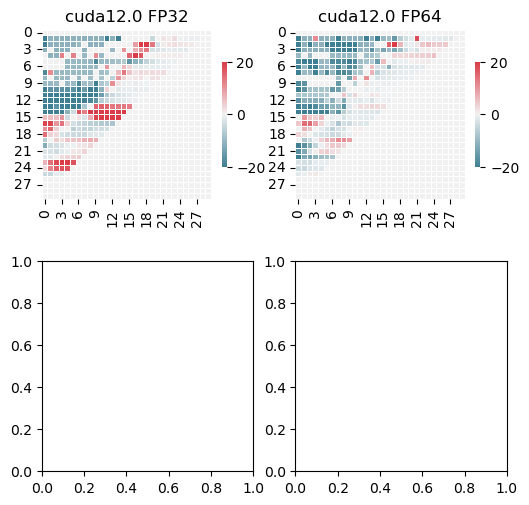

In [114]:
import torch as th
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from random import randint
from utils import load_data, load_data_single
import seaborn as sns

# filename = ['../data_0810/benchmark_cufft_A100_fp32.csv', '../data_0810/benchmark_turbofft_A100_fp32.csv']
filenames = [
        # ['../data_0810/benchmark_cufft_A100_fp32.csv', '../data_0810/benchmark_turbofft_A100_fp32.csv'],
        # ['../data_0810/benchmark_cufft_A100_fp64.csv', '../data_0810/benchmark_turbofft_A100_fp64.csv'],
        # ['../data_0810/cuFFT_fp32_cuda_12.0.csv', '../data_0810/turboFFT_fp32_cuda_12.0.csv'],
        ['../data_0810/cuFFT_fp32_cuda_12.0.csv', '../data_0810//turboFFT_fp32_cuda_12.0_40GB_28.csv'],
        ['../data_0810/cuFFT_fp64_cuda_12.0.csv', '../data_0810/turboFFT_fp64_cuda_12.0.csv'],

        # ['../data_0810/cuFFT_fp32_cuda_12.0_40GB_9.csv', '../data_0810/turboFFT_fp32_cuda_12.0_40GB_28.csv'],
]
fig, ax = plt.subplots(2, 2, figsize=(6, 6))
for j in range(2):
    filename = filenames[j]
    cuFFT = th.ones(30, 30)
    TurboFFT = th.ones(30, 30)

    f_cufft = open(filename[0], 'r')
    f_TurboFFT = open(filename[1], 'r')

    lines_cufft = f_cufft.readlines()
    lines_TurboFFT = f_TurboFFT.readlines()

    for i in range(len(lines_cufft)):
        if lines_cufft[i].split(',')[0] != 'cuFFT' and lines_cufft[i].split(',')[0] != 'turboFFT':
        # if lines_TurboFFT[i].split(',')[0] != 'turboFFT':
            continue
        cuFFT[int(lines_cufft[i].split(',')[1])][int(lines_cufft[i].split(',')[2])] = float(lines_cufft[i].split(',')[3])

    # if j == 
    for i in range(len(lines_TurboFFT)):
        if lines_TurboFFT[i].split(',')[0] != 'turboFFT':
            continue
        TurboFFT[int(lines_TurboFFT[i].split(',')[1])][int(lines_TurboFFT[i].split(',')[2])] = float(lines_TurboFFT[i].split(',')[3])

    # print(TurboFFT[25], cuFFT[25])

    # Plotting the heatmap
    # plt.figure(figsize=(8, 6))
    # plt.imshow(TurboFFT/cuFFT, cmap='viridis')
    # plt.colorbar()
    # plt.title('Heatmap of a 30x30 Torch Tensor')
    # plt.show()
    cmap = sns.diverging_palette(220, 10, as_cmap=True)
    sns_plot = sns.heatmap((TurboFFT/cuFFT) * 100 - 100, cmap=cmap, vmax=20, vmin=-20,center=0,
    # sns_plot = sns.heatmap(TurboFFT/cuFFT * 100 - 100, cmap=cmap,center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, ax=ax[j // 2][j % 2],)
    ax[j//2][j % 2].set_title(f'cuda12.{j//2 * 2} FP{32+32*(j%2)}')
    # print(TurboFFT/cuFFT)

In [178]:
import torch as th
TurboFFT = th.ones(2, 30, 30)
TurboFFT *= 1e6
for i in range(30):
    filename = f'../data_0810/turboFFT_fp32_cuda_12.0_40GB_{i}.csv'
    try:
        f = open(filename, 'r')
    except:
        print('Cannot open file:', filename)
        continue
    lines = f.readlines()
    for line in lines:
        if line.split(',')[0] != 'turboFFT':
            continue
        logN = int(line.split(',')[1])
        logBS = int(line.split(',')[2])
        exec_time = float(line.split(',')[3])
        # if exec_time >= 0.1 * TurboFFT[logN][logBS]:
        if (i == 8 or i == 12) and logN == 13:
            continue
        TurboFFT[0][logN][logBS] = min(TurboFFT[0][logN][logBS], exec_time)
        # if logN==14 and logBS==10:
        #     print(i, exec_time)
        # print(TurboFFT[13][10], i)
filename = '../data_0810/turboFFT_fp64_cuda_12.0.csv'
f = open(filename, 'r')
lines = f.readlines()
    
for line in lines:
    if line.split(',')[0] != 'turboFFT':
        continue
    logN = int(line.split(',')[1])
    logBS = int(line.split(',')[2])
    exec_time = float(line.split(',')[3])
    TurboFFT[1][logN][logBS] = exec_time

TurboFFT[TurboFFT == 1e6] = 1

th.save(TurboFFT, '../data_0810/TurboFFT.pt')


Cannot open file: ../data_0810/turboFFT_fp32_cuda_12.0_40GB_0.csv


In [179]:
filenames = ['../data_0810/cuFFT_fp32_cuda_12.0_40GB.csv',
            '../data_0810/cuFFT_fp64_cuda_12.0.csv']
cuFFT = th.ones(2, 30, 30)
for p in range(2):
    filename = filenames[p]
    f = open(filename, 'r')
    lines_cufft = f.readlines()
    for i in range(len(lines_cufft)):
        if lines_cufft[i].split(',')[0] != 'cuFFT':
            continue
        cuFFT[p][int(lines_cufft[i].split(',')[1])][int(lines_cufft[i].split(',')[2])] = float(lines_cufft[i].split(',')[3])
        
th.save(cuFFT,'../data_0810/cuFFT.pt')

C:\Users\SHIXUNWU\AppData\Local\Temp\ipykernel_18404\703662979.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cuFFT = th.load('../data_0810/cuFFT.pt')
C:\Users\SHIXUNW

torch.Size([2, 30, 30])


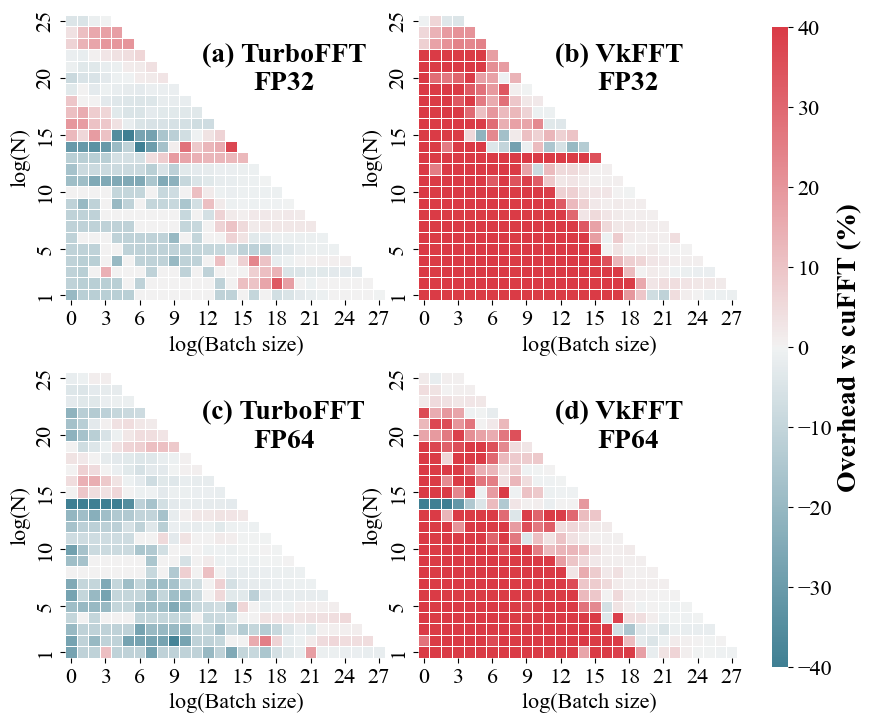

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import torch as th
plt.rcParams["font.family"] = "Times New Roman"
plt.rc('font', size=16,)
cmap = sns.diverging_palette(220, 10, as_cmap=True)
fontsize = 20
logN_beg, logN_end = 1, 26
logBS_beg, logBS_end = 0, 28
cuFFT = th.load('../data_0810/cuFFT.pt')
TurboFFT = th.load('../data_0810/turboFFT.pt')
vkFFT = th.load('../data_0810/vkFFT.pt')

fig, ax = plt.subplots(2, 2, figsize=(8, 8),)
fig.tight_layout()
fig.subplots_adjust(hspace=0, wspace=0.03)
bd = 40
print(cuFFT.shape)
mask = th.ones(30, 30)
for i in range(26):
        mask[i][:28-i+1] = 0
mask = mask.numpy()
mask = mask[1:26]
label = [
    '(a) TurboFFT',
    '(b) VkFFT',
    '(c) TurboFFT',
    '(d) VkFFT',
]
precision = ['FP32', 'FP64']
cbar_ax = fig.add_axes([.96, .1, .02, .8], label='Overhead vs cuFFT (%)')
for i in range(2):
	heatmap = (TurboFFT[i]/cuFFT[i])[1:26] * 100 - 100
	sns_plot = sns.heatmap(heatmap, cmap=cmap,  mask=mask, vmax=bd, vmin=-bd,center=0,
	# sns_plot = sns.heatmap((TurboFFT[i]/cuFFT[i]) * 100 - 100, cmap=cmap, vmax=50, center=0,
			square=True, linewidths=.5, cbar_kws={"shrink": .5}, ax=ax[i, 0],cbar=False)
	# print(vkFFT[:30, :30].shape)
	heatmap = (vkFFT[i]/cuFFT[i])[1:26] * 100 - 100
	sns_plot = sns.heatmap(heatmap, cmap=cmap, mask=mask, vmax=bd, vmin=-bd,center=0,
	# sns_plot = sns.heatmap((vkFFT[i] / cuFFT[i]) * 100 - 100, cmap=cmap, vmax=50, center=0,
			square=True, linewidths=.5, cbar_kws={"shrink": .5}, ax=ax[i, 1],
			cbar_ax=cbar_ax if i == 0 else None, cbar=i == 0)
	ax[i, 0].invert_yaxis()
	ax[i, 1].invert_yaxis()
cbar_ax.set_ylabel('Overhead vs cuFFT (%)', fontdict={'fontsize': fontsize, 'weight': 'bold'})
# fig.colorbar(ax.get_children()[0], orientation="horizontal")

for i in range(2):
	b = 0.1
	ax[i, 0].text(.3 + b, .9, label[i * 2], ha='left', va='top', transform=ax[i, 0].transAxes, fontsize=fontsize, fontdict={'weight': 'bold'})
	ax[i, 1].text(.3 + b, .9, label[i * 2 + 1], ha='left', va='top', transform=ax[i, 1].transAxes, fontsize=fontsize, fontdict={'weight': 'bold'})
	ax[i, 0].text(.45 + b, .8, precision[i], ha='left', va='top', transform=ax[i, 0].transAxes, fontsize=fontsize, fontdict={'weight': 'bold'})
	ax[i, 1].text(.425 + b, .8, precision[i], ha='left', va='top', transform=ax[i, 1].transAxes, fontsize=fontsize, fontdict={'weight': 'bold'})
	for j in range(2):
		b = 0.5
		ax[i, j].set_yticks([0 + b, 4 + b, 9+ b, 14+ b, 19+ b, 24+ b])
		ax[i, j].set_yticklabels([1, 5, 10, 15, 20, 25])
		ax[i, j].set_xticks([i + b for i in range(0, 28, 3)])
		ax[i, j].set_xticklabels([i for i in range(0, 28, 3)])
		
		ax[i, j].set_ylabel('log(N)')
		ax[i, j].set_xlabel('log(Batch size)')

plt.savefig('../figs/TurboFFT_vs_VkFFT_vs_cuFFT.pdf', bbox_inches='tight')

C:\Users\SHIXUNWU\AppData\Local\Temp\ipykernel_2272\3609009510.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cuFFT = th.load('../data_0810/cuFFT.pt')[precision]
C:\Us

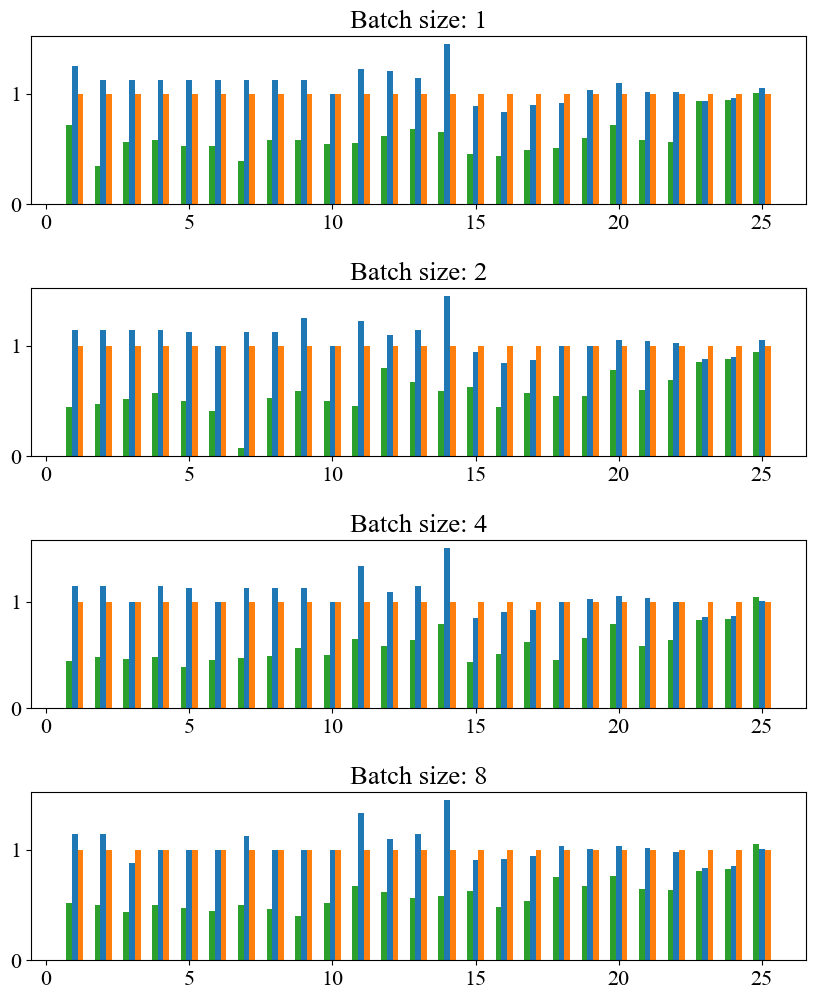

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import torch as th
import numpy as np
plt.rcParams["font.family"] = "Times New Roman"
plt.rc('font', size=16,)
fontsize = 20
logN_beg, logN_end = 1, 26
logBS_beg, logBS_end = 0, 4
precision = 0
cuFFT = th.load('../data_0810/cuFFT.pt')[precision]
TurboFFT = th.load('../data_0810/turboFFT.pt')[precision]
vkFFT = th.load('../data_0810/vkFFT.pt')[precision]
fig, ax = plt.subplots(logBS_end, 1, figsize=(10, 12))
fig.subplots_adjust(hspace=0.5, wspace=0.03)
color = sns.color_palette(n_colors=5)
# ax.plot(TurboFFT[1:,1], label='TurboFFT')
# ax.plot(cuFFT[1:,1], label='cuFFT')
# ax.plot(TurboFFT[1:, 1] / cuFFT[1:,1]

width = 0.2
for i in range(logBS_end):
    x_end = 26 
    x = np.arange(1,x_end)
    select_bs = i
    turboFFT_bar =  cuFFT[1:x_end,select_bs] / TurboFFT[1:x_end, select_bs]
    ax[i].bar(x, width=width, height=turboFFT_bar, color=color[0])
    ax[i].bar(x + width, width=width, height=cuFFT[1:x_end, select_bs] / cuFFT[1:x_end,select_bs], color=color[1])
    ax[i].bar(x - width, width=width, height=cuFFT[1:x_end, select_bs] / vkFFT[1:x_end,select_bs], color=color[2])
    ax[i].set_title(f'Batch size: {2**select_bs}')
# turboFFT_bar = [cuFFT[i, 28 - i] / TurboFFT[i, 28 - i] for i in range(1, x_end)]
# cuFFT_bar = [cuFFT[i, 28 - i] / cuFFT[i, 28 - i] for i in range(1, x_end)]
# vkfft_bar = [cuFFT[i, 28 - i] / vkFFT[0][i, 28 - i] for i in range(1, x_end)]
# select_bs = 
# turboFFT_bar = [cuFFT[i, 28 - i] / TurboFFT[i, 28 - i] for i in range(1, x_end)]
# cuFFT_bar = [cuFFT[i, 28 - i] / cuFFT[i, 28 - i] for i in range(1, x_end)]
# vkfft_bar = [cuFFT[i, 28 - i] / vkFFT[i, 28 - i] for i in range(1, x_end)]
# ax[1].bar(x, width=width, height=turboFFT_bar, color=color[0])
# ax[1].bar(x + width, width=width, height=cuFFT_bar, color=color[1])
# ax[1].bar(x - width, width=width, height=vkfft_bar, color=color[2])


C:\Users\SHIXUNWU\AppData\Local\Temp\ipykernel_2272\801880846.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cuFFT = th.load('../data_0810/cuFFT.pt')[precision]
C:\Use

torch.Size([30]) (30,)
torch.Size([30]) (30,)
torch.Size([30]) (30,)
torch.Size([30]) (30,)


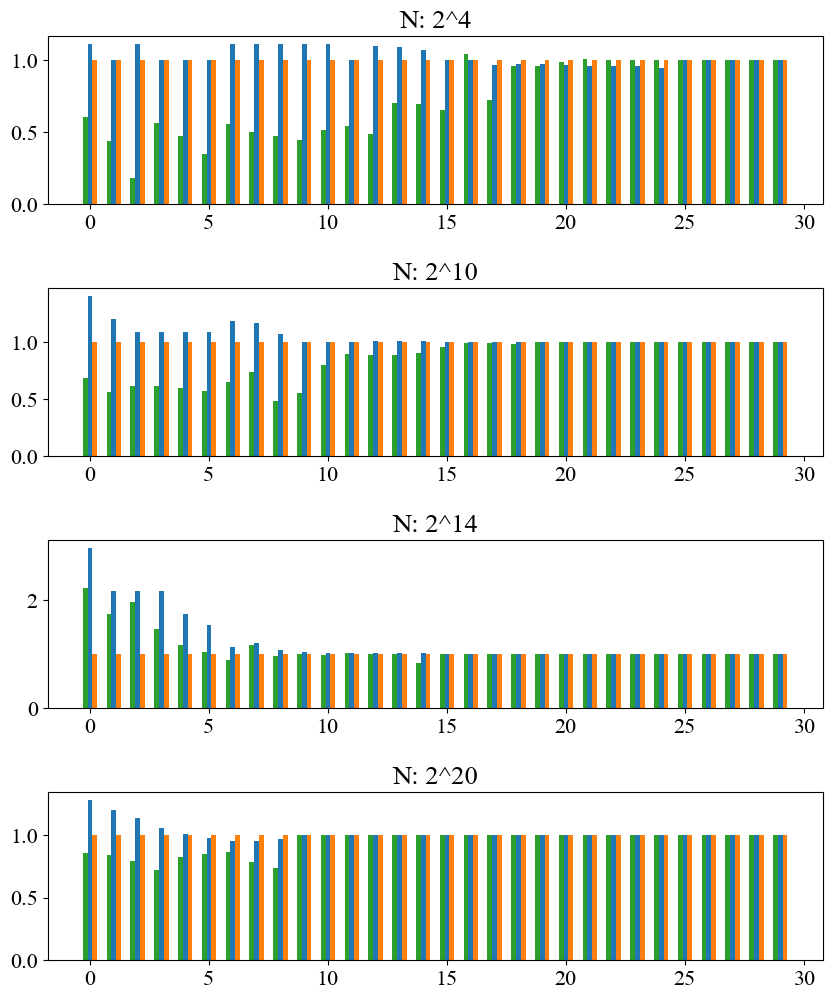

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
import torch as th
import numpy as np
plt.rcParams["font.family"] = "Times New Roman"
plt.rc('font', size=16,)
fontsize = 20
logN_beg, logN_end = 1, 26
logBS_beg, logBS_end = 0, 4
precision = 1
cuFFT = th.load('../data_0810/cuFFT.pt')[precision]
TurboFFT = th.load('../data_0810/turboFFT.pt')[precision]
vkFFT = th.load('../data_0810/vkFFT.pt')[precision]

N_list = [4, 10, 14, 20]
fig, ax = plt.subplots(len(N_list), 1, figsize=(10, 12))
fig.subplots_adjust(hspace=0.5, wspace=0.03)
color = sns.color_palette(n_colors=5)
# ax.plot(TurboFFT[1:,1], label='TurboFFT')
# ax.plot(cuFFT[1:,1], label='cuFFT')
# ax.plot(TurboFFT[1:, 1] / cuFFT[1:,1]

width = 0.2
for i, N in enumerate(N_list):
    begin = 0
    end = 30
    x = np.arange(begin,end)
    select_n = N
    turboFFT_bar =  cuFFT[select_n][begin:end] / TurboFFT[select_n][begin:end]
    print(turboFFT_bar.shape, x.shape)
    ax[i].bar(x, width=width, height=turboFFT_bar, color=color[0])
    ax[i].bar(x + width, width=width, height=cuFFT[select_n][begin:end] / cuFFT[select_n][begin:end], color=color[1])
    ax[i].bar(x - width, width=width, height=cuFFT[select_n][begin:end] / vkFFT[select_n][begin:end], color=color[2])
    ax[i].set_title(f'N: 2^{select_n}')
# turboFFT_bar = [cuFFT[i, 28 - i] / TurboFFT[i, 28 - i] for i in range(1, x_end)]
# cuFFT_bar = [cuFFT[i, 28 - i] / cuFFT[i, 28 - i] for i in range(1, x_end)]
# vkfft_bar = [cuFFT[i, 28 - i] / vkFFT[0][i, 28 - i] for i in range(1, x_end)]
# select_bs = 
# turboFFT_bar = [cuFFT[i, 28 - i] / TurboFFT[i, 28 - i] for i in range(1, x_end)]
# cuFFT_bar = [cuFFT[i, 28 - i] / cuFFT[i, 28 - i] for i in range(1, x_end)]
# vkfft_bar = [cuFFT[i, 28 - i] / vkFFT[i, 28 - i] for i in range(1, x_end)]
# ax[1].bar(x, width=width, height=turboFFT_bar, color=color[0])
# ax[1].bar(x + width, width=width, height=cuFFT_bar, color=color[1])
# ax[1].bar(x - width, width=width, height=vkfft_bar, color=color[2])


C:\Users\SHIXUNWU\AppData\Local\Temp\ipykernel_18968\3526653680.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cuFFT = th.load('../data_0810/cuFFT.pt')[precision]
C:\U

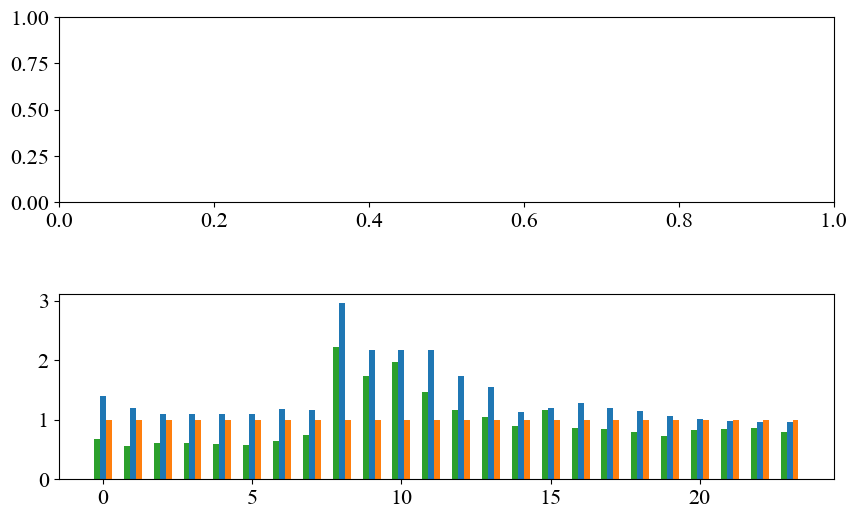

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import torch as th
import numpy as np
import matplotlib
font = {'family' : 'Times New Roman',
        'weight' : 'bold',
        'size'   : 16}
matplotlib.rc('font', **font)
plt.rc('font', size=16,)
fontsize = 20
logN_beg, logN_end = 1, 26
logBS_beg, logBS_end = 0, 4
precision = 1
cuFFT = th.load('../data_0810/cuFFT.pt')[precision]
TurboFFT = th.load('../data_0810/turboFFT.pt')[precision]
vkFFT = th.load('../data_0810/vkFFT.pt')[precision]

N_list = [4, 10, 14, 20]
fig, ax = plt.subplots(2, 1, figsize=(10, 6))
fig.subplots_adjust(hspace=0.5, wspace=0.03)
color = sns.color_palette(n_colors=5)
# A100_fp32_combine = th.cat([cuFFT[0], TurboFFT[0], vkFFT[0]], dim=0)
width = 0.2

def select_data(N, begin, end):
    bar =  cuFFT / TurboFFT
    turboFFT_bar = th.cat([bar[N[0]][begin:end], bar[N[1]][begin:end], bar[N[2]][begin:end]], dim=0)

    bar =  cuFFT / vkFFT
    vkFFT_bar = th.cat([bar[N[0]][begin:end], bar[N[1]][begin:end], bar[N[2]][begin:end]], dim=0)
    
    bar = cuFFT / cuFFT
    cuFFT_bar = th.cat([bar[N[0]][begin:end], bar[N[1]][begin:end], bar[N[2]][begin:end]], dim=0)
    x = np.arange((end - begin) * 3)
    ax[1].bar(x, width=width, height=turboFFT_bar, color=color[0])
    ax[1].bar(x + width, width=width, height=cuFFT_bar, color=color[1])
    ax[1].bar(x - width, width=width, height=vkFFT_bar, color=color[2])

select_data([10, 14, 20], 0, 8)
# for i, N in enumerate(N_list):
#     begin = 0
#     end = 30
#     x = np.arange(begin,end)
#     select_n = N
    
#     print(turboFFT_bar.shape, x.shape)
#     ax[i].bar(x, width=width, height=turboFFT_bar, color=color[0])
#     ax[i].bar(x + width, width=width, height=cuFFT[select_n][begin:end] / cuFFT[select_n][begin:end], color=color[1])
#     ax[i].bar(x - width, width=width, height=cuFFT[select_n][begin:end] / vkFFT[select_n][begin:end], color=color[2])
#     ax[i].set_title(f'N: 2^{select_n}')


C:\Users\SHIXUNWU\AppData\Local\Temp\ipykernel_22224\1275416892.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cuFFT = th.load('../data_0810/cuFFT.pt')[precision]
C:\U

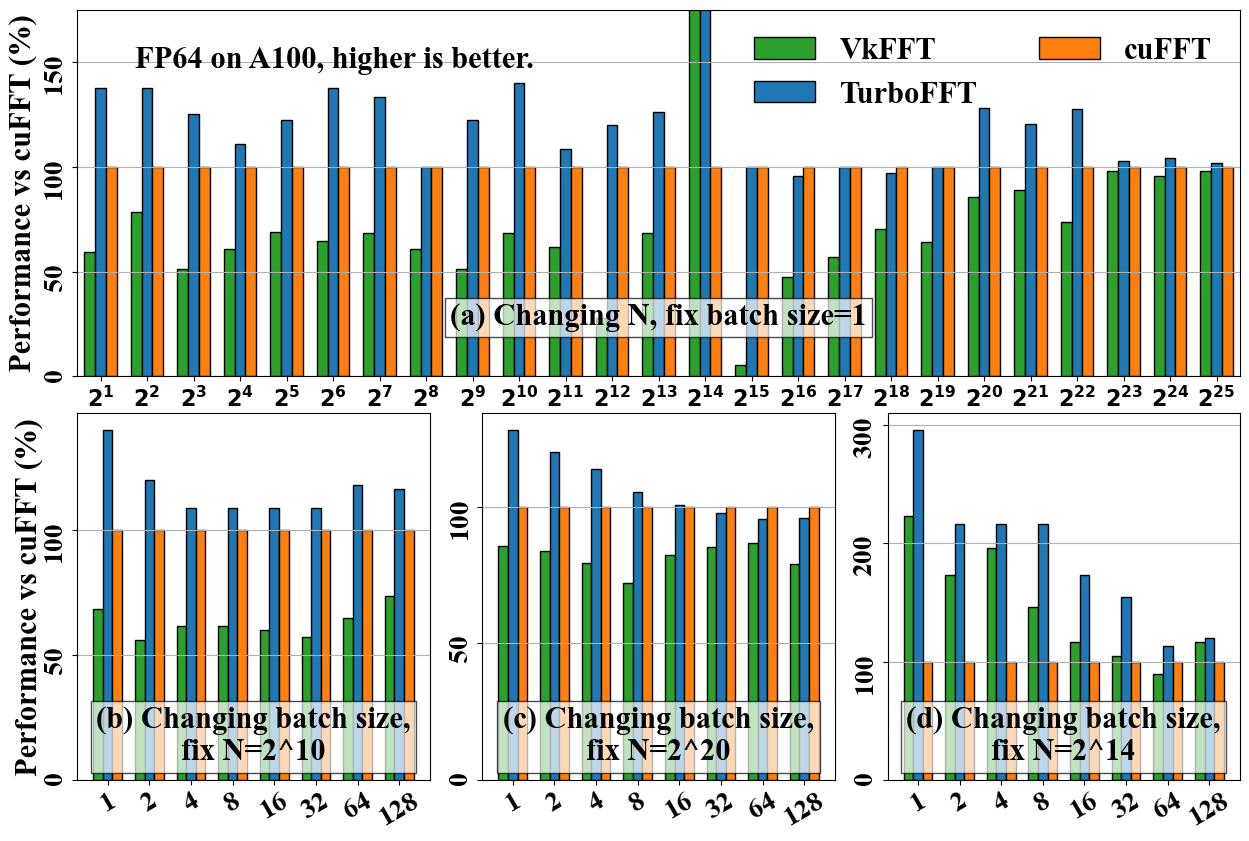

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
import torch as th
import numpy as np
import matplotlib as mpl
# mpl.rcParams['text.usetex'] = True

# # Specify the font: Times New Roman
# mpl.rcParams['text.latex.preamble'] = r'\usepackage{times}'

font = {'family' : 'Times New Roman',
        'weight' : 'bold',
        'size'   : 20}
mpl.rc('font', **font)
gpu = 'A100'
fontsize = 20
logN_beg, logN_end = 1, 26
logBS_beg, logBS_end = 0, 4
precision = 1
cuFFT = th.load('../data_0810/cuFFT.pt')[precision]
TurboFFT = th.load('../data_0810/turboFFT.pt')[precision]
vkFFT = th.load('../data_0810/vkFFT.pt')[precision]

N_list = [4, 10, 14, 20]
# fig, ax = plt.subplots(2, 3, figsize=(15, 10))
fig = plt.figure(figsize=(15, 10))
ax = []
ax.append(fig.add_subplot(2, 1, 1))
tmp_axs = []
tmp_axs.append(fig.add_subplot(2, 3, 4))
tmp_axs.append(fig.add_subplot(2, 3, 5))
tmp_axs.append(fig.add_subplot(2, 3, 6))
ax.append(tmp_axs)

fig.subplots_adjust(hspace=0.1, wspace=0.15)
color = sns.color_palette(n_colors=5)
# A100_fp32_combine = th.cat([cuFFT[0], TurboFFT[0], vkFFT[0]], dim=0)
width = 0.23
# for tmp_ax in ax[0, 1:]:
#     tmp_ax.axis('off')
def select_data(N, begin, end):
    bars = []
    bar =  cuFFT / TurboFFT * 100
    bars.append(bar)
    turboFFT_bar = th.cat([bar[N[0]][begin:end], bar[N[1]][begin:end], bar[N[2]][begin:end]], dim=0)

    bar =  cuFFT / vkFFT * 100
    bars.append(bar)
    vkFFT_bar = th.cat([bar[N[0]][begin:end], bar[N[1]][begin:end], bar[N[2]][begin:end]], dim=0)
    
    bar = cuFFT / cuFFT * 100
    bars.append(bar)
    cuFFT_bar = th.cat([bar[N[0]][begin:end], bar[N[1]][begin:end], bar[N[2]][begin:end]], dim=0)
    x = np.arange(logN_end - logN_beg)
    n = logN_end - logN_beg
    # ax[0].set_ylabel()
    tmp_ax = ax[0]
    tmp_ax.bar(x - width, width=width, height=bars[1][logN_beg:logN_end, 0], color=color[2], label = 'VkFFT', edgecolor='black')
    tmp_ax.bar(x, width=width, height=bars[0][logN_beg:logN_end, 0], color=color[0], label = 'TurboFFT', edgecolor='black')
    tmp_ax.bar(x + width, width=width, height=bars[2][logN_beg:logN_end, 0], color=color[1], label = 'cuFFT', edgecolor='black')
    tmp_ax.set_xticks(x)
    tmp_ax.set_xticklabels(['$2^{' + f'{i}' +'}$' for i in range(1, n + 1, 1)], fontdict={'fontsize': 16, 'weight':'bold'}, rotation=0)
    tmp_ax.text(.05, .9, f'FP{32*(precision+1)} on {gpu}, higher is better.', ha='left', va='top',
                 transform=tmp_ax.transAxes, fontdict={'weight': 'bold', 'fontsize':22} )
    tmp_ax.text(.5, .2, f'(a) Changing N, fix batch size=1', ha='center', va='top',
                transform=tmp_ax.transAxes, fontdict={'weight': 'bold', 'fontsize':22},
                bbox=dict(facecolor='white', alpha=0.7) )
    tmp_ax.grid(axis='y')
    tmp_ax.set_xlim([-0.5, 24.5])

    x = np.arange((end - begin))
    n = end - begin
    id = 'bcde'
    for i in range(3):
        tmp_ax = ax[1][i]
        tmp_ax.bar(x - width, width=width, height=vkFFT_bar[i * n:(i + 1) * n], color=color[2], label = 'VkFFT', edgecolor='black')
        tmp_ax.bar(x, width=width, height=turboFFT_bar[i * n:(i + 1) * n], color=color[0], label='TurboFFT', edgecolor='black')
        tmp_ax.bar(x + width, width=width, height=cuFFT_bar[i * n:(i + 1) * n], color=color[1], label = 'cuFFT', edgecolor='black')
        tmp_ax.text(.5, .2, f'({id[i]}) Changing batch size,\nfix N=2^' + f'{N[i]}' + '', ha='center', va='top', transform=tmp_ax.transAxes, 
                    fontdict={'weight': 'bold', 'fontsize':22},
                    bbox=dict(facecolor='white', alpha=0.7))
       
        tmp_ax.set_xticks(x)
        tmp_ax.set_xticklabels([f'{2**i}' for i in range(n)], fontdict={'fontsize': 20, 'weight':'bold'}, rotation=30)
        # tmp_ax.set_xlabel(f'Batch size\nFix N = 2^{N[i]}', fontdict={'fontsize': 22, 'weight':'bold'})
        tmp_ax.locator_params(axis='y', nbins=4) 
        tmp_ax.tick_params(axis='y', labelsize=20, labelrotation=90)
        tmp_ax.yaxis.labelpad = 0
        tmp_ax.grid(axis='y')

select_data([10, 20, 14], 0, 8)
ax[1][0].set_ylabel('Performance vs cuFFT (%)', fontdict={'fontsize': 22, 'weight':'bold'})
ax[0].set_ylabel('Performance vs cuFFT (%)', fontdict={'fontsize': 22, 'weight':'bold'})
ax[0].tick_params(axis='y', labelsize=20, labelrotation=90)
if precision == 1:
    ax[0].set_ylim([0, 175])
# ax[1][0].legend( ncol=3, fontsize=22, loc=(0.6, -0.28), frameon=False)
ax[0].legend( ncol=2, fontsize=22,  loc='upper right', frameon=False)
fig.savefig('../figs/3xbarchart_overhead_A100_FP32.pdf', bbox_inches='tight')
fig.savefig(f'D:/25_PPOPP_TurboFFT/figs/3xbarchart_overhead_A100_FP{32*(precision + 1)}.pdf', bbox_inches='tight')
# plt.show()
# for i, N in enumerate(N_list):
#     begin = 0
#     end = 30
#     x = np.arange(begin,end)
#     select_n = N
    
#     print(turboFFT_bar.shape, x.shape)
#     ax[i].bar(x, width=width, height=turboFFT_bar, color=color[0])
#     ax[i].bar(x + width, width=width, height=cuFFT[select_n][begin:end] / cuFFT[select_n][begin:end], color=color[1])
#     ax[i].bar(x - width, width=width, height=cuFFT[select_n][begin:end] / vkFFT[select_n][begin:end], color=color[2])
#     ax[i].set_title(f'N: 2^{select_n}')


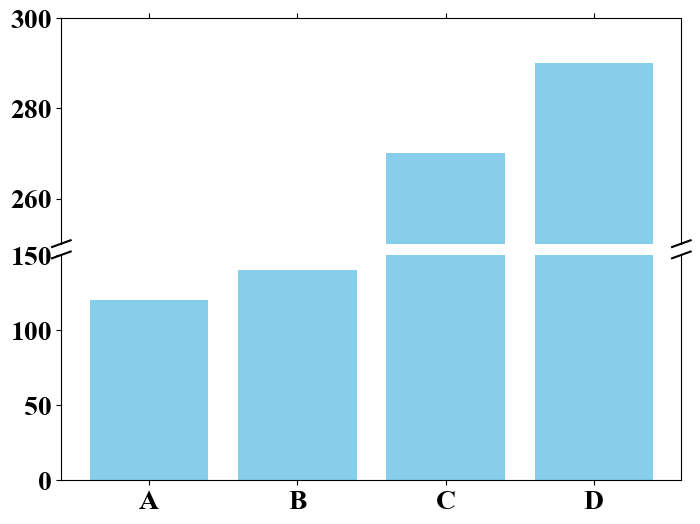

In [ ]:
import matplotlib.pyplot as plt

# Sample data
categories = ['A', 'B', 'C', 'D']
values = [120, 140, 270, 290]

# Create a figure and axes
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 6),
                               gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.05})

# Plot on each subplot
ax1.bar(categories, values, color='skyblue')
ax2.bar(categories, values, color='skyblue')

# Set the y-limits
ax1.set_ylim(250, 300)  # Upper part of the data
ax2.set_ylim(0, 150)    # Lower part of the data

# Hide the spines between ax1 and ax2
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.xaxis.tick_top()
ax1.tick_params(labeltop=False)  # don't put tick labels at the top
ax2.xaxis.tick_bottom()

# Adding diagonal lines to indicate the break
d = .015  # how big to make the diagonal lines in axes coordinates
# arguments to pass to plot, just so we don't keep repeating them
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)        # top-left diagonal
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # top-right diagonal

kwargs.update(transform=ax2.transAxes)  # switch to the bottom axes
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # bottom-left diagonal
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # bottom-right diagonal

# Show the plot
plt.show()

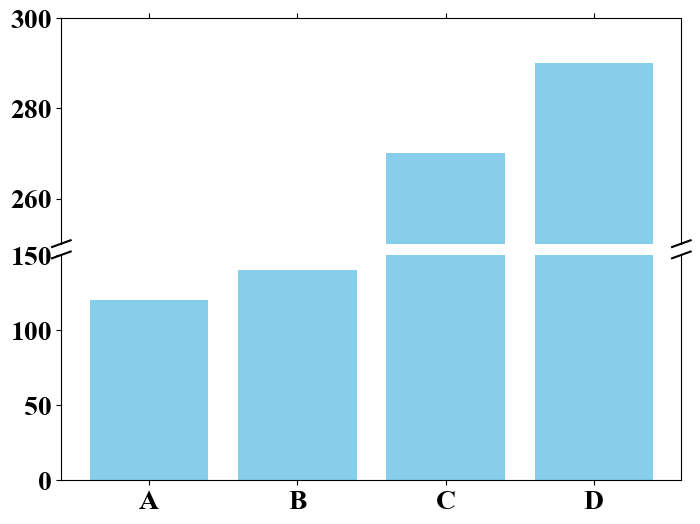

In [32]:
import matplotlib.pyplot as plt

# Sample data
categories = ['A', 'B', 'C', 'D']
values = [120, 140, 270, 290]

# Create a figure and axes
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 6),
                               gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.05})

# Plot on each subplot
ax1.bar(categories, values, color='skyblue')
ax2.bar(categories, values, color='skyblue')

# Set the y-limits
ax1.set_ylim(250, 300)  # Upper part of the data
ax2.set_ylim(0, 150)    # Lower part of the data

# Hide the spines between ax1 and ax2
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.xaxis.tick_top()
ax1.tick_params(labeltop=False)  # don't put tick labels at the top
ax2.xaxis.tick_bottom()

# Adding diagonal lines to indicate the break
d = .015  # how big to make the diagonal lines in axes coordinates
# arguments to pass to plot, just so we don't keep repeating them
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)        # top-left diagonal
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # top-right diagonal

kwargs.update(transform=ax2.transAxes)  # switch to the bottom axes
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # bottom-left diagonal
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # bottom-right diagonal

# Show the plot
plt.show()

In [63]:

import torch as th
TurboFFT_FT = th.zeros(2, 8, 30, 30)

# p = 0
for p in range(2):
    precision = 32 + 32 * p
    filename_list = [f'../data/benchmark_offline_A100_fp{precision}.csv', f'..\data_ft\FP{precision}_A100_FT_THREAD.csv'] + [f'..\data_ft\FP{precision}_A100_FT_{2 ** i}.csv' for 
                    i in range(6)]
    # f = f'..\data_ft\FP32_A100_FT_THREAD.csv'
    # TurboFFT_FT[p][0][logN][logBS] = exec_time
    for i, f in enumerate(filename_list):
        f = open(f, 'r')
        lines = f.readlines()
        for line in lines:
            splitted = line.split(',')
            if splitted[0] != 'turboFFT' and splitted[0] != 'cuFFT':
                continue
            logN = int(splitted[1])
            logBS = int(splitted[2])
            exec_time = float(splitted[3])
            # if  i >= 1 and exec_time <= 0.5 * TurboFFT_FT[p][0][logN][logBS]:
            #     exec_time = TurboFFT_FT[p][1][logN][logBS]
            # if TurboFFT_FT[p][i][logN][logBS] == 0:
            TurboFFT_FT[p][i][logN][logBS] = exec_time
            # else:
            #     TurboFFT_FT[p][i][logN][logBS] = min(exec_time, TurboFFT_FT[p][i][logN][logBS])
th.save(TurboFFT_FT, '../data_0810/TurboFFT_FT.pt')
    

C:\Users\SHIXUNWU\AppData\Local\Temp\ipykernel_22224\926951774.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cuFFT = th.load('../data_0810/cuFFT.pt')[p, 1:26]
C:\User

torch.Size([25, 30])


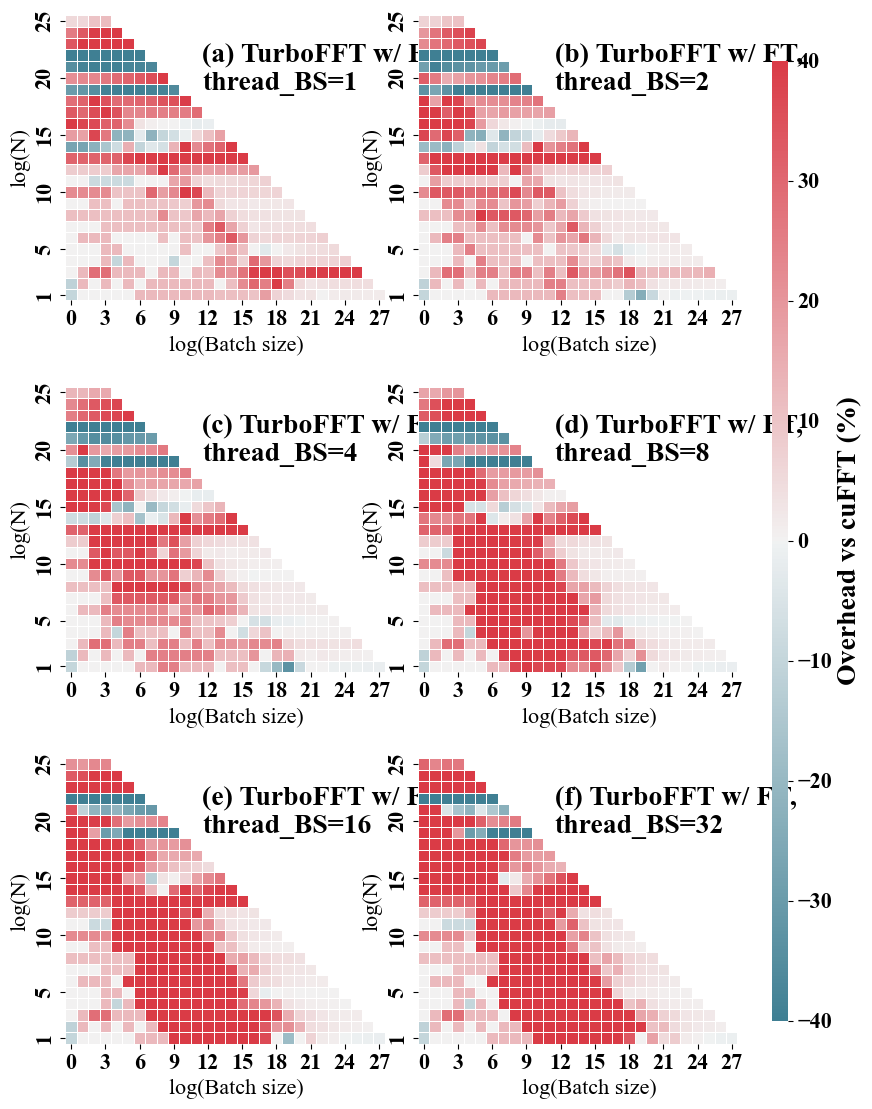

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt
import torch as th
plt.rcParams["font.family"] = "Times New Roman"
plt.rc('font', size=16,)
cmap = sns.diverging_palette(220, 10, as_cmap=True)
fontsize = 20
logN_beg, logN_end = 1, 26
logBS_beg, logBS_end = 0, 28
p = 0
precision = ['FP32', 'FP64']
cuFFT = th.load('../data_0810/cuFFT.pt')[p, 1:26]
TurboFFT = th.load('../data_0810/turboFFT.pt')[p, 1:26]
TurboFFT_FT = th.load('../data_0810/TurboFFT_FT.pt')[p,:, 1:26]
vkFFT = th.load('../data_0810/vkFFT.pt')

fig, ax = plt.subplots(3, 2, figsize=(8, 12),)
fig.tight_layout()
fig.subplots_adjust(hspace=0, wspace=0.03)
bd = 40
print(cuFFT.shape)
mask = th.ones(30, 30)
for i in range(26):
        mask[i][:28-i+1] = 0
mask = mask.numpy()
mask = mask[1:26]
letter_id = 'abcdef'
label = []
for i in range(6):
	label.append(f'({letter_id[i]}) TurboFFT w/ FT,\nthread_BS={2**i}')
cbar_ax = fig.add_axes([.96, .1, .02, .8], label='Overhead vs cuFFT (%)')
for i in range(3):
	heatmap = (TurboFFT_FT[i * 2]/cuFFT) * 100 - 100
	sns_plot = sns.heatmap(heatmap, cmap=cmap,  mask=mask, vmax=bd, vmin=-bd,center=0,
	# sns_plot = sns.heatmap((TurboFFT[i]/cuFFT[i]) * 100 - 100, cmap=cmap, vmax=50, center=0,
			square=True, linewidths=.5, cbar_kws={"shrink": .5}, ax=ax[i, 0],cbar=False)
	# print(vkFFT[:30, :30].shape)
	heatmap = (TurboFFT_FT[i * 2 + 1]/cuFFT) * 100 - 100
	sns_plot = sns.heatmap(heatmap, cmap=cmap, mask=mask, vmax=bd, vmin=-bd,center=0,
	# sns_plot = sns.heatmap((vkFFT[i] / cuFFT[i]) * 100 - 100, cmap=cmap, vmax=50, center=0,
			square=True, linewidths=.5, cbar_kws={"shrink": .5}, ax=ax[i, 1],
			cbar_ax=cbar_ax if i == 0 else None, cbar=i == 0)
	ax[i, 0].invert_yaxis()
	ax[i, 1].invert_yaxis()
cbar_ax.set_ylabel('Overhead vs cuFFT (%)', fontdict={'fontsize': fontsize, 'weight': 'bold'})
# fig.colorbar(ax.get_children()[0], orientation="horizontal")

for i in range(3):
	b = 0.1
	ax[i, 0].text(.3 + b, .9, label[i * 2], ha='left', va='top', transform=ax[i, 0].transAxes, fontsize=fontsize, fontdict={'weight': 'bold'})
	ax[i, 1].text(.3 + b, .9, label[i * 2 + 1], ha='left', va='top', transform=ax[i, 1].transAxes, fontsize=fontsize, fontdict={'weight': 'bold'})
	# ax[i, 0].text(.45 + b, .8, precision[i], ha='left', va='top', transform=ax[i, 0].transAxes, fontsize=fontsize, fontdict={'weight': 'bold'})
	# ax[i, 1].text(.425 + b, .8, precision[i], ha='left', va='top', transform=ax[i, 1].transAxes, fontsize=fontsize, fontdict={'weight': 'bold'})
	for j in range(2):
		b = 0.5
		ax[i, j].set_yticks([0 + b, 4 + b, 9+ b, 14+ b, 19+ b, 24+ b])
		ax[i, j].set_yticklabels([1, 5, 10, 15, 20, 25])
		ax[i, j].set_xticks([i + b for i in range(0, 28, 3)])
		ax[i, j].set_xticklabels([i for i in range(0, 28, 3)])
		
		ax[i, j].set_ylabel('log(N)')
		ax[i, j].set_xlabel('log(Batch size)')

# plt.savefig('../figs/TurboFFT_vs_VkFFT_vs_cuFFT.pdf', bbox_inches='tight')

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt
import torch as th
plt.rcParams["font.family"] = "Times New Roman"
plt.rc('font', size=16,)
cmap = sns.diverging_palette(220, 10, as_cmap=True)
fontsize = 20
logN_beg, logN_end = 1, 26
logBS_beg, logBS_end = 0, 28
p = 0
precision = ['FP32', 'FP64']
cuFFT = th.load('../data_0810/cuFFT.pt')[p, 1:26]
TurboFFT = th.load('../data_0810/turboFFT.pt')[p, 1:26]
TurboFFT_FT = th.load('../data_0810/TurboFFT_FT.pt')[p,:, 1:26]
vkFFT = th.load('../data_0810/vkFFT.pt')
nrows = 8
# fig, ax = plt.subplots(nrows, 2, figsize=(8, 2 + nrows * 3),)
# fig.tight_layout()
# fig.subplots_adjust(hspace=0, wspace=0.03)
bd_max = 100
bd_min = -100
print(cuFFT.shape)
mask = th.ones(30, 30)
for i in range(26):
        mask[i][:28-i+1] = 0
mask = mask.numpy()
mask = mask[1:26]
letter_id = 'abcdef'
label = ['TruboFFT Offline', 'TurboFFT w/ FT,\nThread-Level']
for i in range(6):
	label.append(f'({letter_id[i]}) TurboFFT w/ FT,\nthread_BS={2**i}')
# cbar_ax = fig.add_axes([.96, .1, .02, .8], label='Overhead vs cuFFT (%)')
TurboFFT_FT_best = th.ones(25, 30) * 1e6
result = []
for i in range(nrows):
	TurboFFT_FT[i][TurboFFT_FT[i] < 0.9* TurboFFT] = 1e6
	tmp_result = []
	heatmap = (th.min(TurboFFT_FT_best, TurboFFT_FT[i])/TurboFFT_FT_best) * 100 - 100
	# heatmap = (TurboFFT_FT[i][TurboFFT_FT[i] < TurboFFT_FT_best]/TurboFFT_FT[0]) * 100 - 100
	tmp_result.append(heatmap)
	TurboFFT_FT_best = th.min(TurboFFT_FT_best, TurboFFT_FT[i])
	# sns_plot = sns.heatmap(heatmap, cmap=cmap,  mask=mask, vmax=bd_max, vmin=bd_min,center=0,
	# # sns_plot = sns.heatmap((TurboFFT[i]/cuFFT[i]) * 100 - 100, cmap=cmap, vmax=50, center=0,
	# 		square=True, linewidths=.5, cbar_kws={"shrink": .5}, ax=ax[i, 0],cbar=False)
	# print(vkFFT[:30, :30].shape)
	heatmap = (TurboFFT_FT_best/cuFFT) * 100 - 100
	tmp_result.append(heatmap)
	# heatmap = (TurboFFT_FT_best/TurboFFT) * 100 - 100
	# sns_plot = sns.heatmap(heatmap.to(int), cmap=cmap, mask=mask, vmax=bd_max, vmin=bd_min,center=0,
	# sns_plot = sns.heatmap((vkFFT[i] / cuFFT[i]) * 100 - 100, cmap=cmap, vmax=50, center=0,
			# square=True, linewidths=.5, cbar_kws={"shrink": .5}, ax=ax[i, 1],
			# cbar_ax=cbar_ax if i == 0 else None, cbar=i == 0, annot=True, fmt="d", annot_kws={"size": 6})
	# ax[i, 0].invert_yaxis()
	# ax[i, 1].invert_yaxis()
	result.append(tmp_result)
	# print(TurboFFT_FT_best[-1][:4], TurboFFT[-1][:4], cuFFT[-1][:4], heatmap[-1][:4])
	# assert 0
# cbar_ax.set_ylabel('Overhead vs TurboFFT (%)', fontdict={'fontsize': fontsize, 'weight': 'bold'})
# fig.colorbar(ax.get_children()[0], orientation="horizontal")

# for i in range(nrows):
# 	b = 0.1
# 	ax[i, 0].text(.3 + b, .9, label[i], ha='left', va='top', transform=ax[i, 0].transAxes, fontsize=fontsize, fontdict={'weight': 'bold'})
# 	ax[i, 1].text(.3 + b, .9, label[i], ha='left', va='top', transform=ax[i, 1].transAxes, fontsize=fontsize, fontdict={'weight': 'bold'})
# 	# ax[i, 0].text(.45 + b, .8, precision[i], ha='left', va='top', transform=ax[i, 0].transAxes, fontsize=fontsize, fontdict={'weight': 'bold'})
# 	# ax[i, 1].text(.425 + b, .8, precision[i], ha='left', va='top', transform=ax[i, 1].transAxes, fontsize=fontsize, fontdict={'weight': 'bold'})
# 	for j in range(2):
# 		b = 0.5
# 		ax[i, j].set_yticks([0 + b, 4 + b, 9+ b, 14+ b, 19+ b, 24+ b])
# 		ax[i, j].set_yticklabels([1, 5, 10, 15, 20, 25])
# 		ax[i, j].set_xticks([i + b for i in range(0, 28, 3)])
# 		ax[i, j].set_xticklabels([i for i in range(0, 28, 3)])
		
# 		ax[i, j].set_ylabel('log(N)')
# 		ax[i, j].set_xlabel('log(Batch size)')

# plt.savefig('../figs/TurboFFT_vs_VkFFT_vs_cuFFT.pdf', bbox_inches='tight')


torch.Size([25, 30])


C:\Users\SHIXUNWU\AppData\Local\Temp\ipykernel_24768\2743291611.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cuFFT = th.load('../data_0810/cuFFT.pt')[p, 1:26]
C:\Use

In [52]:
sum_turbofft = 0
sum_cufft = 0
cnt = 0
for i in range(25):
    for j in range(28 - i):
        cnt += 1
        sum_turbofft += TurboFFT_FT_best[i, j] / TurboFFT[i, j]
        sum_cufft += TurboFFT_FT_best[i, j] / cuFFT[i, j]
        print(TurboFFT_FT_best[i, j] / TurboFFT[i, j], TurboFFT_FT_best[i, j] / cuFFT[i, j])
print('TurboFFT', sum_turbofft / cnt)
print('cuFFT', sum_cufft / cnt)

tensor(1.1250) tensor(0.9000)
tensor(1.1429) tensor(1.)
tensor(1.1429) tensor(1.)
tensor(1.1429) tensor(1.)
tensor(1.1429) tensor(1.)
tensor(1.1429) tensor(1.)
tensor(1.) tensor(1.)
tensor(1.) tensor(1.)
tensor(1.1250) tensor(1.1250)
tensor(1.1250) tensor(1.1250)
tensor(1.1250) tensor(1.1250)
tensor(1.1250) tensor(1.1250)
tensor(1.1250) tensor(1.1250)
tensor(1.1250) tensor(1.)
tensor(1.1250) tensor(1.)
tensor(1.) tensor(1.)
tensor(1.1111) tensor(1.)
tensor(1.) tensor(1.)
tensor(0.9286) tensor(0.8667)
tensor(1.0500) tensor(1.)
tensor(0.9091) tensor(0.8824)
tensor(1.) tensor(0.9831)
tensor(1.) tensor(0.9908)
tensor(0.9952) tensor(0.9952)
tensor(0.9901) tensor(0.9926)
tensor(0.9900) tensor(0.9912)
tensor(0.9868) tensor(0.9868)
tensor(0.9861) tensor(0.9852)
tensor(1.1250) tensor(1.)
tensor(1.2857) tensor(1.1250)
tensor(1.2857) tensor(1.1250)
tensor(1.2857) tensor(1.1250)
tensor(1.2857) tensor(1.1250)
tensor(1.1250) tensor(1.1250)
tensor(1.1250) tensor(1.)
tensor(1.1250) tensor(1.1250)
tens

C:\Users\SHIXUNWU\AppData\Local\Temp\ipykernel_24768\877827845.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cuFFT = th.load('../data_0810/cuFFT.pt')[p, 1:26]
C:\User

torch.Size([25, 30])


C:\Users\SHIXUNWU\AppData\Local\Temp\ipykernel_24768\877827845.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


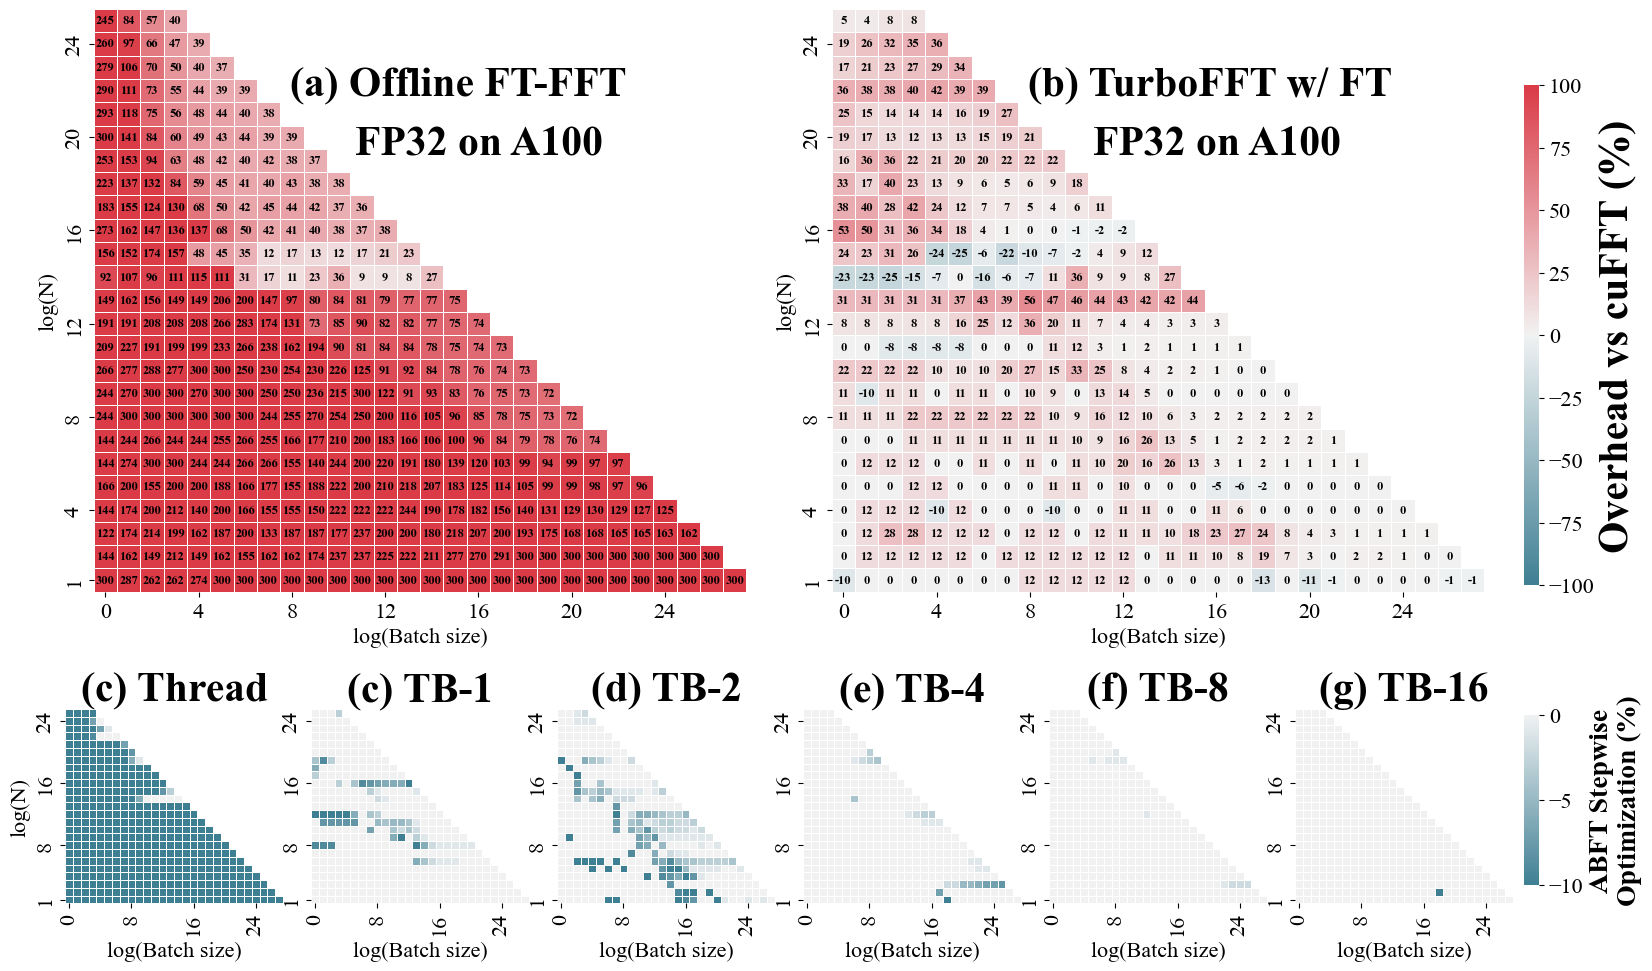

In [171]:
# TurboFFT tensor(1.1361)
# cuFFT tensor(1.0662)
# TurboFFT tensor(1.1448)
# cuFFT tensor(1.1079)
import seaborn as sns
import matplotlib.pyplot as plt
import torch as th
plt.rcParams["font.family"] = "Times New Roman"
plt.rc('font', size=16,)
cmap = sns.diverging_palette(220, 10, as_cmap=True)
fontsize = 20
logN_beg, logN_end = 1, 26
logBS_beg, logBS_end = 0, 28
p = 0
precision = ['FP32', 'FP64']
cuFFT = th.load('../data_0810/cuFFT.pt')[p, 1:26]
TurboFFT = th.load('../data_0810/turboFFT.pt')[p, 1:26]
TurboFFT_FT = th.load('../data_0810/TurboFFT_FT.pt')[p,:, 1:26]
vkFFT = th.load('../data_0810/vkFFT.pt')
nrows = 8
# fig, ax = plt.subplots(nrows, 2, figsize=(8, 2 + nrows * 3),)
# fig.tight_layout()
# fig.subplots_adjust(hspace=0, wspace=0.03)
bd_max = 100
bd_min = -100
print(cuFFT.shape)
mask = th.ones(30, 30)
for i in range(26):
        mask[i][:28-i+1] = 0
mask = mask.numpy()
mask = mask[1:26]
letter_id = 'abcdef'
label = ['TruboFFT Offline', 'TurboFFT w/ FT,\nThread-Level']
for i in range(6):
	label.append(f'({letter_id[i]}) TurboFFT w/ FT,\nthread_BS={2**i}')
TurboFFT_FT_best = th.ones(25, 30) * 1e6
result = []
for i in range(nrows):
	TurboFFT_FT[i][TurboFFT_FT[i] < 0.9* TurboFFT] = 1e6
	tmp_result = []
	heatmap = (th.min(TurboFFT_FT_best, TurboFFT_FT[i])/TurboFFT_FT_best) * 100 - 100
	tmp_result.append(heatmap)
	TurboFFT_FT_best = th.min(TurboFFT_FT_best, TurboFFT_FT[i])
	heatmap = (TurboFFT_FT_best/cuFFT) * 100 - 100
	tmp_result.append(heatmap)
	result.append(tmp_result)

fig = plt.figure(figsize=(15, 10))
fig.tight_layout()
fig.subplots_adjust(hspace=-0.5, wspace=-1)
gs = fig.add_gridspec(2, 6, height_ratios=[3, 1])
cbar_ax = [None, 
           fig.add_axes([.99, .4, .01, .5], label='Overhead vs cuFFT (%)'),
           None, None, None, None, None,
            fig.add_axes([.99, .1, .01, .17], label='Overhead vs Previous FT (%)'),
            ]
axs = []
axs.append(fig.add_subplot(gs[0, 0:3]))  # Merging first three positions for subplot 1
axs.append(fig.add_subplot(gs[0, 3:6]))  # Merging next two positions for subplot 2
label = ['(a) Offline FT-FFT', '(b) TurboFFT w/ FT', '(c) Thread']
letter_id = 'abcdefgh'
for i in range(6):
	label.append(f'({letter_id[i + 2]}) TB-{2**i}')
for i in range(6):
    axs.append(fig.add_subplot(gs[1, i]))
id_i = [0, -1, 1, 2, 3, 4, 5, 6]
id_j = [1, 1, 0, 0, 0, 0, 0, 0]
bd_max = [100, 100, 0, 0, 0, 0, 0, 0]
bd = -10
bd_min = [-100, -100, bd, bd, bd, bd, bd, bd]
ftsize = 9
for i in range(8):
    ax = axs[i]
    heatmap = result[id_i[i]][id_j[i]]
    sns_plot = sns.heatmap(
        heatmap.to(int).clamp(max=300)[:, :28], cmap=cmap, mask=mask[:, :28], vmax=bd_max[i], vmin=bd_min[i],center=0,
        square=True, linewidths=.5, cbar_kws={"shrink": .5}, ax=ax,
        cbar_ax=cbar_ax[i], cbar=cbar_ax[i]!=None, annot=i<2, fmt="d", annot_kws={"size": ftsize, "weight": 'bold', 'color': 'black'})
    ax.invert_yaxis()
    title_fontsize = 30 if i < 2 else 30
    if i < 2:
        ax.text(.3, .9, label[i], ha='left', va='top', 
                transform=ax.transAxes, fontsize=title_fontsize, 
                fontdict={'weight': 'bold'})
        b = 0.5
        ax.set_yticks([i + b for i in range(0, 25)])
        ax.set_yticklabels([i + 1 for i in range(0, 25)])
        ax.set_yticks([0 + b, 3 + b, 7 + b, 11 + b, 15 + b, 19 + b, 23+ b])
        ax.set_yticklabels([1, 4, 8, 12, 16, 20, 24])
        ax.set_xticks([0 + b, 4 + b, 8 + b, 12 + b, 16 + b, 20 + b, 24+ b])
        ax.set_xticklabels(['0', '4', '8', '12',  '16', '20', '24'])
        ax.text(.4, .8, f'{precision[p]} on A100', ha='left', va='top', transform=ax.transAxes, fontsize=title_fontsize, fontdict={'weight': 'bold'})
    else:
        ax.set_title(label[i], fontdict={'fontsize': title_fontsize, 'weight': 'bold'})
        
        b = 0.5
        ax.set_yticks([0 + b, 7 + b, 15 + b, 23+ b])
        ax.set_yticklabels([1, 8, 16, 24])
        ax.set_xticks([0 + b, 8 + b, 16 + b, 24+ b])
        ax.set_xticklabels(['0', '8', '16', '24'])
    if i < 3:
        ax.set_ylabel('log(N)')
        
    ax.set_xlabel('log(Batch size)')
    # ax.invert_yaxis()
cbar_ax[1].set_ylabel('Overhead vs cuFFT (%)', fontdict={'fontsize': 30, 'weight': 'bold'})
cbar_ax[-1].set_ylabel('ABFT Stepwise\nOptimization (%)', fontdict={'fontsize': 20, 'weight': 'bold'})
plt.tight_layout()
fig.savefig(f'../figs/ABFT_stepwise_optimization_A100_FP{32*(p + 1)}.pdf', bbox_inches='tight')
fig.savefig(f'D:/25_PPOPP_TurboFFT/figs/ABFT_stepwise_optimization_A100_FP{32*(p + 1)}.pdf', bbox_inches='tight')
